## Hartman-Grobman Theorem
$\newcommand{\xstar}{x^{\star}}$
$\newcommand{\R}{{\Bbb R}}$
https://en.wikipedia.org/wiki/Hartman–Grobman_theorem

### Hypotheses
1. Let $U$ be an **open neighborhood** of $x^{\star}$ in ${\Bbb R}^n$.  That is $U$ is open (all points of $U$ are interior points) and contains $x^{\star}$.

2. Let $f:U\to{\Bbb R}^n$ be $C^{1}$ on $U$ (continuous partial derivatives of the components w.r.t. the usual coordinates).

3. Let $J$ be the Jacobian matrix
$$
    J = [J_{ij}] = [\partial f_i/\partial x_j].
$$

4. Let $\phi(t,y_0)=\phi^t(y_0)=\phi_{y_0}(t)$ be the **flow** for 
\begin{equation}
    \dot y = f(y),\qquad y(0)=y_0. \tag{IVP}
\end{equation}
That is, for each initial condition $y_0\in U$, $\phi_{y_0}(t)$ satisfies (IVP) on some open interval about $t=0$. 

5. Suppose $x^{\star}$ is an **equilibrium point** (or **fixed point**) for $f$.  That is, $f(x^{\star})=0$ hence
$$
    \phi(t,x^{\star}) \equiv x^{\star}.
$$

6. Suppose $A=J(x^{\star})$ is **hyperbolic**.  That is, all eigenvalues of $A$ have nonzero real part.

### Conclusion
#### Then
1. there is a **neighborhood** $N$ of $x^{\star}$ (a set with $x^{\star}$ in its interior), 

2. a neighborhood $V$ of $0$ in ${\Bbb R}^n$, and

3. a **homeomorphism** $h:N\to V$, that is $h$ is continuous, invertible, and its inverse is continuous

#### such that
* under the change of coordinates $x=h(y)$ the flow $\phi$ is topologically conjugate to the flow for the linear system
$$
    \dot x = Ax\qquad x(t_0) = x_0
$$
which as we now know is $e^{At}x_0$.  That is, $h(\phi(t,y_0))=e^{At}x_0$ with $x_0=h(y_0)$.

## Linear Systems in ${\Bbb R}^2$.

Two distinct real eigenvalues (or one of geometric multiplicity two).
$$
    J_1 = \begin{bmatrix} \lambda_1 & 0 \cr 0 & \lambda_2 \end{bmatrix}
$$

A complex congjugate pair of eigenvalues
$$
    J_2 = \begin{bmatrix} \alpha & \beta \cr -\beta & \alpha \end{bmatrix}
$$

Exactly one eigenvalue of geometric multiplicity one
$$
    J_3 = \begin{bmatrix} \lambda_1 & 1 \cr 0 & \lambda_1 \end{bmatrix}
$$

In [1]:
import numpy as np, numpy.linalg as LA, math
from math import pi as π
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

In [2]:
λ1,λ2 = -1.,2.
def ϕ(t,xy0):
    x0,y0 = xy0
    return np.vstack((x0*np.exp(λ1*t),y0*np.exp(λ2*t)))

In [8]:
tsteps,nsols =100,500
t0,t1 = 0,2
t = np.linspace(t0,t1,tsteps+1)
sols = []
xy0s = 2*np.random.rand(2,nsols)-1
special = np.array([(1,0),(-1,0),(0,1e-2),(0,-1e-2)]).T
xy0s = np.concatenate((xy0s,special),axis=1)
for xy0 in xy0s.T:
    sols.append(ϕ(t,xy0))

<IPython.core.display.Javascript object>


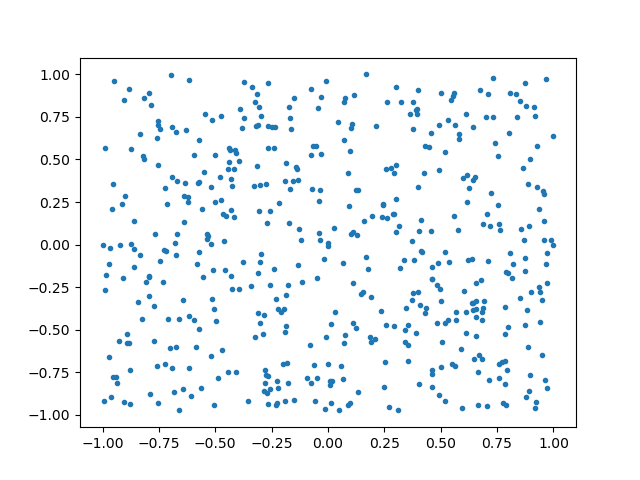

In [9]:
x,y = xy0s
plt.plot(x,y,'.')

In [10]:
%matplotlib notebook

<IPython.core.display.Javascript object>


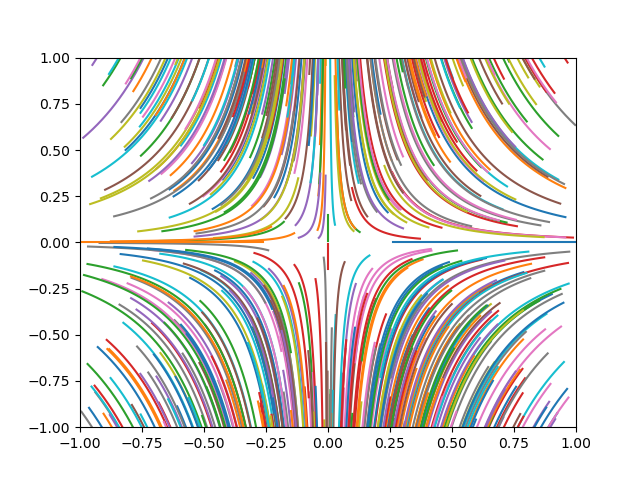

In [11]:
fig,ax = plt.subplots()
lns = []

for sol in sols:
    ln, = plt.plot([],[])
    lns.append(ln)

def init():
    ax.set_xlim(-1,1)
    ax.set_ylim(-1,1)

def update(frame):
    for sol,ln in zip(sols,lns):
        x,y = sol
        ln.set_data(x[:frame],y[:frame])
    return lns[0]

ani = FuncAnimation(fig,update,frames=range(1,tsteps+1),init_func=init)

plt.show()

In [12]:
P = np.array([[2,1],[1,2]])
P

array([[2, 1],
       [1, 2]])

In [13]:
J = np.diag((λ1,λ2))
A = P @ J @ LA.inv(P)
A

array([[-2.,  2.],
       [-2.,  3.]])

In [14]:
Pinv = LA.inv(P)
Pinv

array([[ 0.66666667, -0.33333333],
       [-0.33333333,  0.66666667]])

In [15]:
def ϕ(t,xy0):
    x0,y0 = Pinv @ xy0
    return P @ np.vstack((x0*np.exp(λ1*t),y0*np.exp(λ2*t)))

In [16]:
sols = []
for xy0 in xy0s.T:
    sols.append(ϕ(t,xy0))

<IPython.core.display.Javascript object>


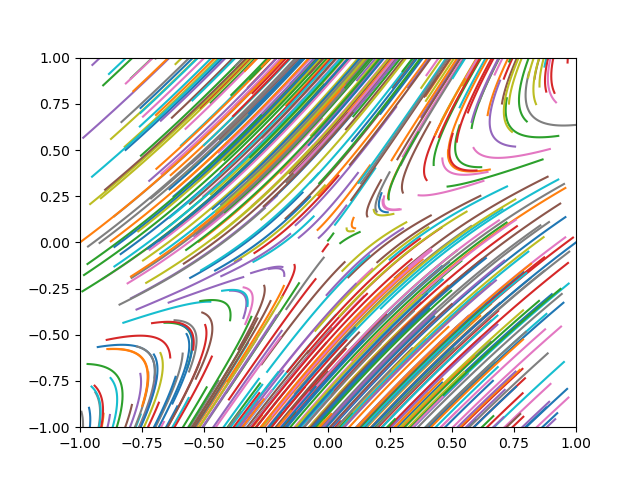

In [20]:
fig,ax = plt.subplots()
lns = []

for sol in sols:
    ln, = plt.plot([],[])
    lns.append(ln)

def init():
    ax.set_xlim(-1,1)
    ax.set_ylim(-1,1)

def update(frame):
    for sol,ln in zip(sols,lns):
        x,y = sol
        ln.set_data(x[:frame],y[:frame])
    return lns[0]

ani = FuncAnimation(fig,update,frames=range(1,tsteps+1),init_func=init)

plt.show()

<IPython.core.display.Javascript object>


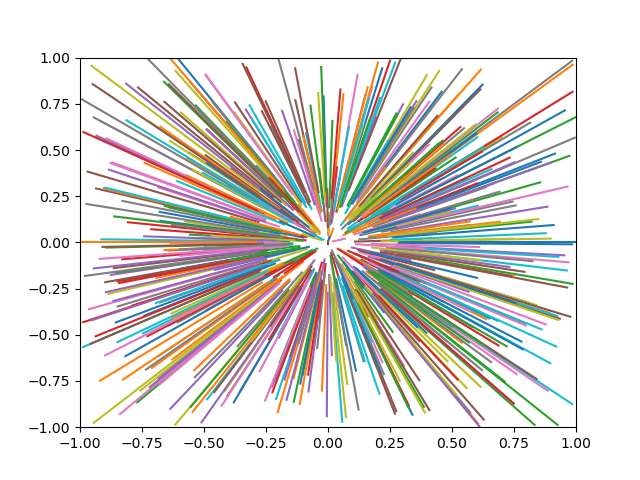

In [21]:
λ1,λ2 = -1.,-1.
t0,t1 = 0,2
tsteps,nsols = 100,500

def ϕ(t,xy0):
    x0,y0 = xy0
    return np.vstack((x0*np.exp(λ1*t),y0*np.exp(λ2*t)))

t = np.linspace(t0,t1,tsteps+1)
sols = []
xy0s = 2*np.random.rand(2,nsols)-1
special = np.array([(1,0),(-1,0),(0,1e-2),(0,-1e-2)]).T
xy0s = np.concatenate((xy0s,special),axis=1)
for xy0 in xy0s.T:
    sols.append(ϕ(t,xy0))

fig,ax = plt.subplots()
lns = []

for sol in sols:
    ln, = plt.plot([],[])
    lns.append(ln)

def init():
    ax.set_xlim(-1,1)
    ax.set_ylim(-1,1)

def update(frame):
    for sol,ln in zip(sols,lns):
        x,y = sol
        ln.set_data(x[:frame],y[:frame])
    return lns[0]

ani = FuncAnimation(fig,update,frames=range(1,tsteps+1),init_func=init)

plt.show()

<IPython.core.display.Javascript object>


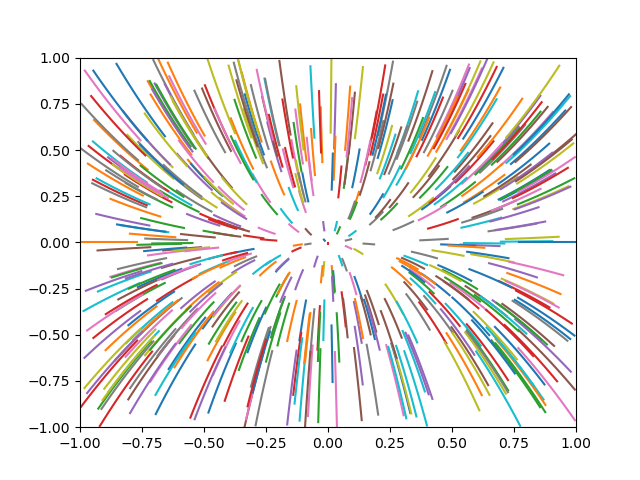

In [22]:
λ1,λ2 = -1.,-2.
t0,t1 = 0,2
tsteps,nsols = 100,500

def ϕ(t,xy0):
    x0,y0 = xy0
    return np.vstack((x0*np.exp(λ1*t),y0*np.exp(λ2*t)))

t = np.linspace(t0,t1,tsteps+1)
sols = []
xy0s = 2*np.random.rand(2,nsols)-1
special = np.array([(1,0),(-1,0),(0,1e-2),(0,-1e-2)]).T
xy0s = np.concatenate((xy0s,special),axis=1)
for xy0 in xy0s.T:
    sols.append(ϕ(t,xy0))

fig,ax = plt.subplots()
lns = []

for sol in sols:
    ln, = plt.plot([],[])
    lns.append(ln)

def init():
    ax.set_xlim(-1,1)
    ax.set_ylim(-1,1)

def update(frame):
    for sol,ln in zip(sols,lns):
        x,y = sol
        ln.set_data(x[:frame],y[:frame])
    return lns[0]

ani = FuncAnimation(fig,update,frames=range(1,tsteps+1),init_func=init)

plt.show()

<IPython.core.display.Javascript object>


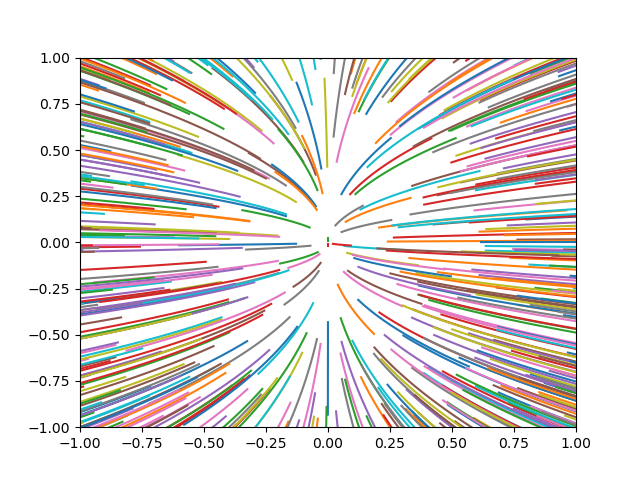

In [23]:
λ1,λ2 = 1.,0.5
t0,t1 = 0,2
tsteps,nsols = 100,500

def ϕ(t,xy0):
    x0,y0 = xy0
    return np.vstack((x0*np.exp(λ1*t),y0*np.exp(λ2*t)))

t = np.linspace(t0,t1,tsteps+1)
sols = []
xy0s = 2*np.random.rand(2,nsols)-1
special = np.array([(1,0),(-1,0),(0,1e-2),(0,-1e-2)]).T
xy0s = np.concatenate((xy0s,special),axis=1)
for xy0 in xy0s.T:
    sols.append(ϕ(t,xy0))

fig,ax = plt.subplots()
lns = []

for sol in sols:
    ln, = plt.plot([],[])
    lns.append(ln)

def init():
    ax.set_xlim(-1,1)
    ax.set_ylim(-1,1)

def update(frame):
    for sol,ln in zip(sols,lns):
        x,y = sol
        ln.set_data(x[:frame],y[:frame])
    return lns[0]

ani = FuncAnimation(fig,update,frames=range(1,tsteps+1),init_func=init)

plt.show()

<IPython.core.display.Javascript object>


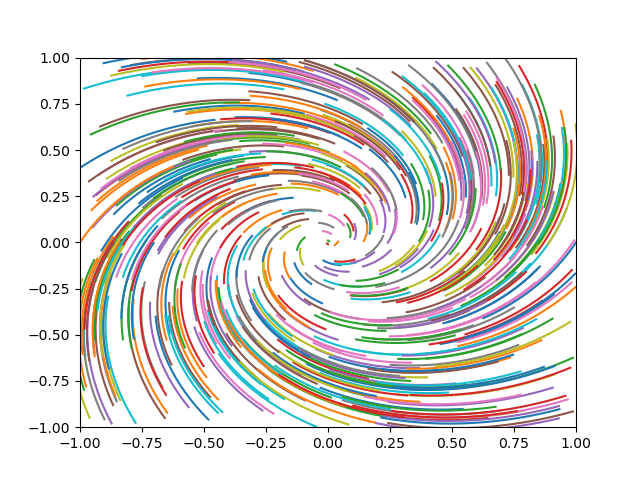

In [24]:
α,β = -0.5,1
t0,t1 = 0,2
tsteps,nsols = 100,500

def ϕ(t,xy0):
    x0,y0 = xy0
    x = np.exp(α*t)*(np.cos(β*t)*x0+np.sin(β*t)*y0)
    y = np.exp(α*t)*(-np.sin(β*t)*x0+np.cos(β*t)*y0)
    return np.vstack((x,y))

t = np.linspace(t0,t1,tsteps+1)
sols = []
xy0s = 2*np.random.rand(2,nsols)-1
xy0s = np.concatenate((xy0s,special),axis=1)
for xy0 in xy0s.T:
    sols.append(ϕ(t,xy0))

fig,ax = plt.subplots()
lns = []

for sol in sols:
    ln, = plt.plot([],[])
    lns.append(ln)

def init():
    ax.set_xlim(-1,1)
    ax.set_ylim(-1,1)

def update(frame):
    for sol,ln in zip(sols,lns):
        x,y = sol
        ln.set_data(x[:frame],y[:frame])
    return lns[0]

ani = FuncAnimation(fig,update,frames=range(1,tsteps+1),init_func=init)

plt.show()

<IPython.core.display.Javascript object>


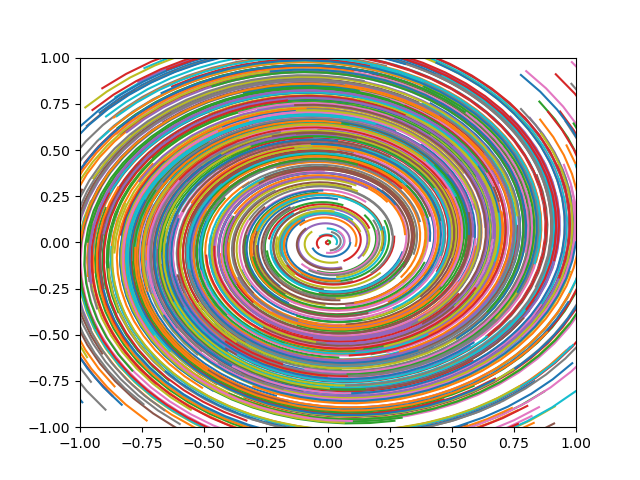

In [25]:
α,β = -0.5,5
t0,t1 = 0,2
tsteps,nsols = 100,500

def ϕ(t,xy0):
    x0,y0 = xy0
    x = np.exp(α*t)*(np.cos(β*t)*x0+np.sin(β*t)*y0)
    y = np.exp(α*t)*(-np.sin(β*t)*x0+np.cos(β*t)*y0)
    return np.vstack((x,y))

t = np.linspace(t0,t1,tsteps+1)
sols = []
xy0s = 2*np.random.rand(2,nsols)-1
xy0s = np.concatenate((xy0s,special),axis=1)
for xy0 in xy0s.T:
    sols.append(ϕ(t,xy0))

fig,ax = plt.subplots()
lns = []

for sol in sols:
    ln, = plt.plot([],[])
    lns.append(ln)

def init():
    ax.set_xlim(-1,1)
    ax.set_ylim(-1,1)

def update(frame):
    for sol,ln in zip(sols,lns):
        x,y = sol
        ln.set_data(x[:frame],y[:frame])
    return lns[0]

ani = FuncAnimation(fig,update,frames=range(1,tsteps+1),init_func=init)

plt.show()

<IPython.core.display.Javascript object>


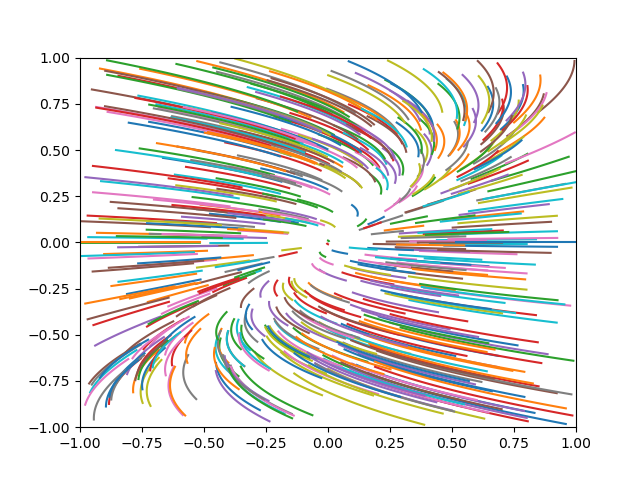

In [26]:
λ1 = -1.
t0,t1 = 0,2
tsteps,nsols = 100,500

def ϕ(t,xy0):
    x0,y0 = xy0
    x = np.exp(λ1*t)*(x0+t*y0)
    y = np.exp(α*t)*y0
    return np.vstack((x,y))

t = np.linspace(t0,t1,tsteps+1)
sols = []
xy0s = 2*np.random.rand(2,nsols)-1
special = np.array([(1,0),(-1,0),(0,1e-2),(0,-1e-2)]).T
xy0s = np.concatenate((xy0s,special),axis=1)
for xy0 in xy0s.T:
    sols.append(ϕ(t,xy0))

fig,ax = plt.subplots()
lns = []

for sol in sols:
    ln, = plt.plot([],[])
    lns.append(ln)

def init():
    ax.set_xlim(-1,1)
    ax.set_ylim(-1,1)

def update(frame):
    for sol,ln in zip(sols,lns):
        x,y = sol
        ln.set_data(x[:frame],y[:frame])
    return lns[0]

ani = FuncAnimation(fig,update,frames=range(1,tsteps+1),init_func=init)

plt.show()

## Pendulum problem, ignoring friction
Total energy
$$
    E = -mg\ell\cos\theta + {1\over 2} m \ell^2(\dot\theta)^2
$$

conservation of energy implies
$$
        0 = mg\ell \sin\theta \dot\theta + m\ell^2\dot\theta\ddot\theta
$$

or
$$
    \ddot\theta =-{g\over\ell}\sin\theta
$$

## Friction included
$$
    \ddot\theta =-{g\over\ell}\sin\theta - 2\alpha \dot\theta
$$

$x_1=\theta$, $x_2=\dot\theta$

\begin{align}
    \dot x_1 &= x_2\cr
    \dot x_2 &= -\frac{g}{\ell}\sin(x_1) - 2\alpha x_2\cr
\end{align}

In [27]:
g,ℓ = 9.81,1.0
α = 0.

In [28]:
def J(x1,x2):
    return np.array([
        [0.,                1],
        [-g*np.cos(x1)/ℓ,-2*α]
    ])

In [29]:
J(0,0)

array([[ 0.  ,  1.  ],
       [-9.81, -0.  ]])

In [30]:
LA.eig(J(0,0))[0]

array([ 0.+3.13209195j, -0.-3.13209195j])

In [32]:
LA.eig(J(π,0))[0]

array([ 3.13209195, -3.13209195])